In [1]:
import random
import json
import os, sys
from importlib import reload
from pathlib import Path
import numpy as np
import pandas as pd

import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from transformers import AutoTokenizer

random.seed(6)
np.random.seed(6)

hugg_auth_token = os.environ.get("HUGGINGFACE_KEY")


In [2]:
# My modules

WORK_DIR = Path.cwd().parent
sys.path.append(str(WORK_DIR))

from src import (
    response_processing as rp,
    graph_gen,
    video_tools)


In [5]:
# Files
STAR_VAL_SMALL = WORK_DIR / "data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json"
VQA_OUTPUT = WORK_DIR / "outputs/vqa_videochatgpt2_complex_2stage_prompting.jsonl"

RAW_VIDEO_DIR = Path(WORK_DIR / 'data/datasets/action-genome/Charades_v1_480/')
SAVE_VIDEO_DIR = Path(WORK_DIR / "experiments/video_dump")


## Loading GT

In [3]:
with open(WORK_DIR / 'data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json') as f:
    ground_truth = json.load(f)


gt_df = pd.DataFrame(ground_truth).astype({'question_id': 'string', 'answer': 'string'})
gt_df.rename(columns={"question_id": "id", "answer": "text"}, inplace=True)
gt_df.set_index('id', inplace=True)
gt_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1048 entries, Feasibility_T5_102 to Interaction_T4_4181
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   question          1048 non-null   object 
 1   video_id          1048 non-null   object 
 2   start             1048 non-null   float64
 3   end               1048 non-null   float64
 4   text              1048 non-null   string 
 5   question_program  1048 non-null   object 
 6   choices           1048 non-null   object 
 7   situations        1048 non-null   object 
dtypes: float64(2), object(5), string(1)
memory usage: 73.7+ KB


## Loading predicted answers evaluation

In [ ]:
predictions = pd.read_json(VQA_OUTPUT, lines=True)
predictions.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048 entries, 0 to 1047
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   qid               1048 non-null   object
 1   question_id       1048 non-null   object
 2   prompt            1048 non-null   object
 3   ground_truth      1048 non-null   object
 4   generated_answer  1048 non-null   object
 5   chat_history      1048 non-null   object
dtypes: object(6)
memory usage: 49.2+ KB


In [ ]:
predictions = predictions.set_index('qid', drop=True)
predictions


,question_id,prompt,ground_truth,generated_answer,chat_history
qid,,,,,
Feasibility_T5_102,Feasibility_T5_102,<start_header_id|>user<|end_header_id|>You are...,The clothes.,The final answer is A. The blanket.,"[{'role': 'user', 'content': 'You are an intel..."
Feasibility_T2_860,Feasibility_T2_860,<start_header_id|>user<|end_header_id|>You are...,Close the window.,The final answer is C. close the window.,"[{'role': 'user', 'content': 'You are an intel..."
Feasibility_T2_556,Feasibility_T2_556,<start_header_id|>user<|end_header_id|>You are...,Open the closet/cabinet.,"Based on the provided video, it is evident tha...","[{'role': 'user', 'content': 'You are an intel..."
Prediction_T1_2539,Prediction_T1_2539,<start_header_id|>user<|end_header_id|>You are...,Sit on the floor.,"The most plausible answer is A: ""Sit on the fl...","[{'role': 'user', 'content': 'You are an intel..."
Prediction_T4_1253,Prediction_T4_1253,<start_header_id|>user<|end_header_id|>You are...,The shoe.,Based on the provided alternatives and the vid...,"[{'role': 'user', 'content': 'You are an intel..."
...,...,...,...,...,...
Interaction_T1_8913,Interaction_T1_8913,<start_header_id|>user<|end_header_id|>You are...,The paper/notebook.,The person took a cup or a glass from the tabl...,"[{'role': 'user', 'content': 'You are an intel..."
Interaction_T1_8967,Interaction_T1_8967,<start_header_id|>user<|end_header_id|>You are...,The dish.,The correct answer is A) the towel.,"[{'role': 'user', 'content': 'You are an intel..."
Interaction_T2_1847,Interaction_T2_1847,<start_header_id|>user<|end_header_id|>You are...,Took.,The person in the video is most likely interac...,"[{'role': 'user', 'content': 'You are an intel..."


In [54]:
print(predictions.iloc[1]['chat_history'][0]['content'])


You are an intelligent video comprehension model and are going to receive as input a sequence of images extracted from a video and a question. You need to analyze and describe the scene unfolding in the video (sequence of frames) following these guidelines:
1. Look for recurring objects;
2. Note that the same object may appear differently across frames due to low image quality, varying viewing angles, or partial obstructions. Carefully check objects with similar features (e.g. shape, color), appearing in different frames, as they may still be the same object;
3. Pay attention to how the person interacts with its environment
4. Understand the directional movement of the people and objects in the video
5. Carefully analyze the chronological sequence of the events occurring in the video;
6. Pay attention to the atomic and fine grained movement, pose and actions of the people in the video. Compose these atomic actions happening across the frame to infer the higher level action performed by

In [55]:
print(predictions.iloc[0]['chat_history'][-1]['content'])


The final answer is A. The blanket.


In [ ]:
pattern = re.compile(r"[A-E]\.\s*([^.]{1,40})")
test_str = "A. This is a test string. B. It contains multiple sentences. R. Each sentence is prefixed with a letter and a period."
matches = pattern.findall(test_str)
print(matches)


['This is a test string', 'It contains multiple sentences']


In [ ]:
test_str = "No match"
matches = pattern.findall(test_str)
print(matches)


[]


In [ ]:
pattern.findall(predictions.iloc[0]['chat_history'][-1]['content'])


['The blanket']

In [ ]:
predictions['pred_answer'] = predictions['chat_history'].apply(lambda x: matches[0] if (matches := pattern.findall(x[-1]['content'])) else "")
predictions['pred_answer'] = predictions['pred_answer'].str.strip()
predictions['pred_answer']


qid
Feasibility_T5_102                   The blanket
Feasibility_T2_860              close the window
Feasibility_T2_556                              
Prediction_T1_2539                              
Prediction_T4_1253                              
                                 ...            
Interaction_T1_8913             The cup or glass
Interaction_T1_8967                             
Interaction_T2_1847        the paper or notebook
Interaction_T2_3423                       Closed
Interaction_T4_4181    Putting down the sandwich
Name: pred_answer, Length: 1048, dtype: object

In [ ]:
predictions['ground_truth'] = gt_df['text'].reindex(predictions.index)
predictions['correct'] = predictions['ground_truth'].str.replace('\.', '').str.lower() == predictions['pred_answer'].str.replace('\.', '').str.lower()
predictions['correct'].value_counts()


correct
False    1048
Name: count, dtype: Int64

In [ ]:
predictions.iloc[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]][['ground_truth', 'pred_answer', 'correct']]


,ground_truth,pred_answer,correct
qid,,,
Feasibility_T5_102,The clothes.,The blanket,False
Feasibility_T2_860,Close the window.,close the window,False
Feasibility_T2_556,Open the closet/cabinet.,,False
Prediction_T1_2539,Sit on the floor.,,False
Prediction_T4_1253,The shoe.,,False
Interaction_T1_5612,The laptop.,The person is opening the window,False
Feasibility_T5_1851,The laptop.,,False
Prediction_T2_450,Take.,Take the clothes and put them into the w,False
Feasibility_T5_1670,The dish.,The clothes,False


In [13]:
pred_sgg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
eval_df2 = gt_df.join(
    pred_sgg_df.loc[pred_sgg_df['contains_answer']], 
    how='inner' # we account also for samples without answers
)
rp.print_acc(eval_df2, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          189        42.86%  
Sequence             202        46.04%  
Prediction           171        36.26%  
Feasibility          162        37.04%  

Average              724        40.88%  


In [14]:
rp.print_ans_perc(eval_df2, gt_df)


Question type       Total      Answered 

Interaction          298        63.42%  
Sequence             291        69.42%  
Prediction           239        71.55%  
Feasibility          220        73.64%  
Overall             1048        69.08%  


### Why is the accuracy with the generated SG as base so low?

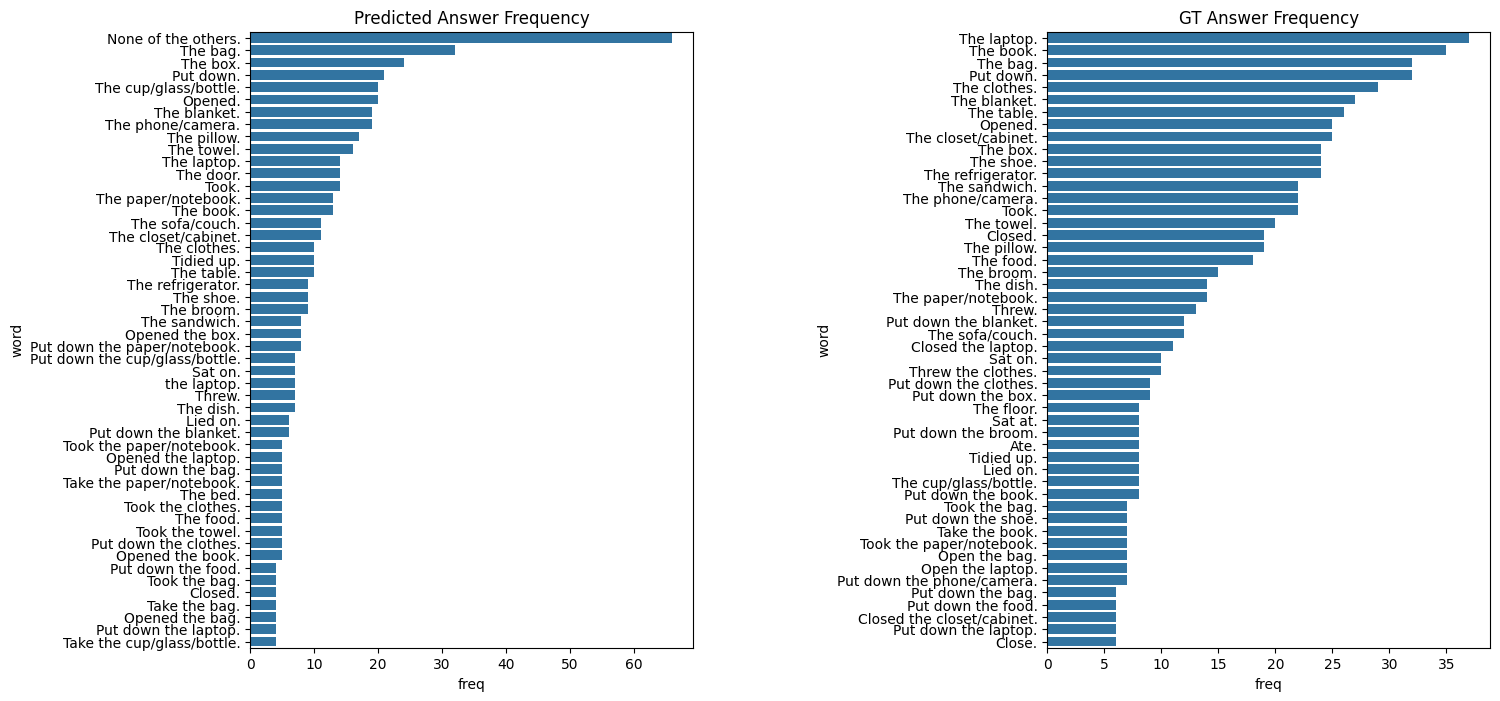

In [15]:
freq_pred = pred_sgg_df['pred_text'].value_counts().reset_index()
freq_pred.columns = ["word", "freq"]

freq_gt = gt_df['text'].value_counts().reset_index()
freq_gt.columns = ["word", "freq"]


fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 8),
    gridspec_kw={'wspace': 0.8}   # adjust wspace to taste
)

sns.barplot(
    data=freq_pred.sort_values('freq', ascending=False)[:50],
    x="freq", y="word",
    ax=axes[0]
)
axes[0].set_title("Predicted Answer Frequency")

sns.barplot(
    data=freq_gt.sort_values('freq', ascending=False)[:50],
    x="freq", y="word",
    ax=axes[1]
)

axes[1].set_title("GT Answer Frequency")
plt.show()


That's way. For > half of the Q the model answers with None of the others.

<Axes: xlabel='freq', ylabel='word'>

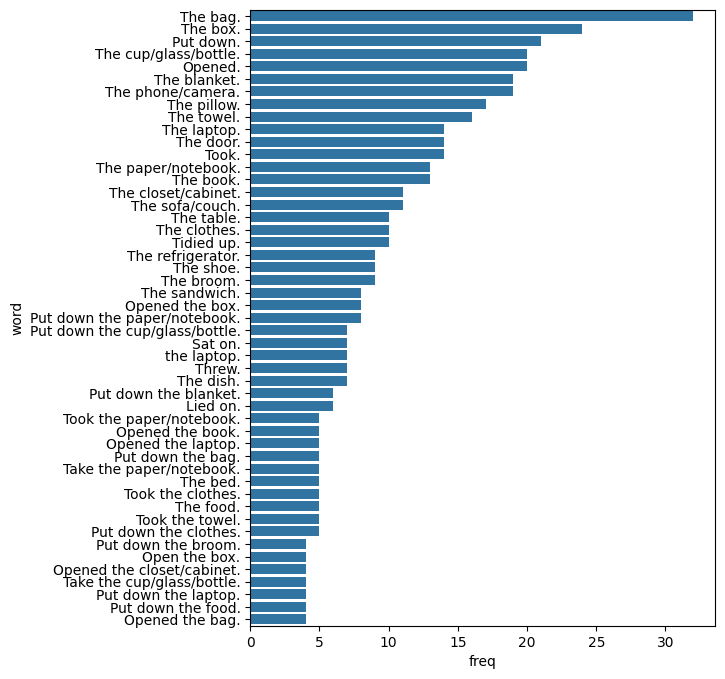

In [16]:
plt.figure(figsize=(6, 8))
sns.barplot(data=freq_pred.iloc[1:50], x='freq', y='word')


### Reasoning token length

In [17]:
gemma3_tokenizer = AutoTokenizer.from_pretrained(
    "google/gemma-3-4b-it",
    auth_token=hugg_auth_token
)


/home/lusha/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


ValueError: Tokenizer class GemmaTokenizer does not exist or is not currently imported.

Reasoning length:

In [ ]:
reasoning_token_len_sgg = pred_sgg_df['chat_history'].apply(lambda x: len(gemma3_tokenizer.tokenize(x[1]['content'])))
reasoning_token_len_sgg.describe()


count    1042.000000
mean      624.315739
std       284.389221
min       338.000000
25%       506.000000
50%       561.500000
75%       628.750000
max      2048.000000
Name: chat_history, dtype: float64

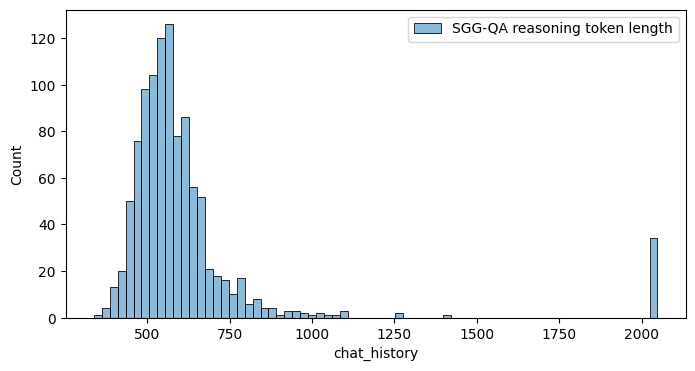

In [ ]:
plt.figure(figsize=(8,4))

sns.histplot(reasoning_token_len_sgg, alpha=.5, label="SGG-QA reasoning token length")
plt.legend()


The reasoning token is not too different form other experiments.

In [ ]:
with open(WORK_DIR / 'data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json') as f:
    ground_truth = json.load(f)


gt_df = pd.DataFrame(ground_truth).astype({'question_id': 'string', 'answer': 'string'})
gt_df.rename(columns={"question_id": "id", "answer": "text"}, inplace=True)
gt_df.set_index('id', inplace=True)
gt_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1048 entries, Feasibility_T5_102 to Interaction_T4_4181
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   question          1048 non-null   object 
 1   video_id          1048 non-null   object 
 2   start             1048 non-null   float64
 3   end               1048 non-null   float64
 4   text              1048 non-null   string 
 5   question_program  1048 non-null   object 
 6   choices           1048 non-null   object 
 7   situations        1048 non-null   object 
dtypes: float64(2), object(5), string(1)
memory usage: 73.7+ KB
